# Quadratic Programming

In this topic, you’ll learn what a quadratic program (or QP) is, and learn how quadratic programming applies to portfolio management.

## Quadratic Functions

Mathematically, a function is quadratic if: 
- The variables are only first or second degree (that is, one variable may be multiplied by another variable, and any of the variables may be squared) and
- The coefficients of the variables are constant numeric values (that is, integers or real numbers). 

A quadratic function is also known as a second degree polynomial function. 

Geometrically, a quadratic function is a curve or curved surface. For example, a quadratic function in two dimensions is a curved line, such as a parabola, hyperbola, ellipse, or circle. 

## What is a Quadratic Program?


Quadratic Programs (or QPs) have quadratic objectives and linear constraints. A model that has quadratic functions in the constraints is a Quadratically Constrained Program (or QCP). The objective function of a QCP may be quadratic or linear.  
A simple formulation of a QP is:

$$
	{minimize}\ \frac{1}{2}{x^{t}Qx + c^{t}x}\\ 
subject\ to \\
\ \ 	Ax \ge b \\
\ \ 	lb \le x \le ub \\
$$

The first objective term is quadratic, with Q being the matrix of objective function coefficients of the quadratic terms.  The second term and the constraints are linear. CPLEX Optimizer can solve convex QP and QCP problems. Quadratic programming is used in several real-world situations, for example portfolio management or chemical process modeling. In the next two slides, you’ll see how QP applies to portfolio management. 

A model that has quadratic functions in the constraints is a Quadratically Constrained Program (QCP). The objective function of a QCP problem may be quadratic or linear. 

## Portfolio management

In order to mitigate risk while ensuring a reasonable level of return, investors purchase a variety of securities and combine these into an investment portfolio. Each security has an expected return and an associated level of risk (or variance). 

Securities sometimes covary, that is, they change together with some classes of securities, and in the opposite direction of other classes of securities. An example of positive covariance is when shares in technology companies follow similar patterns of increases and decreases in value. On the other hand, as the price of oil rises, shares in oil companies may increase in value, but plastics manufacturers, who depend on petroleum as a major primary resource, may see their shares decline in value as their costs go up and vice versa. This is negative covariance. 

To optimize a portfolio in terms of risk and return, an investor will evaluate the sum of expected returns of the securities, the total variances of the securities, and the covariances of the securities.  A portfolio that contains a large number of positively covariant securities is more risky (and potentially more rewarding) than one that contains a mix of positively and negatively covariant securities. 

### Potfolio optimization: what use?

Portfolio optimization is used to select securities to maximize the rate of return, while managing the volatility of the portfolio and remaining within the investment budget. 

As the securities covary with one another, selecting the right mix of securities can change or even reduce the volatility of the portfolio with the same expected return. 

At a given expected rate of return, there is one portfolio which has the lowest risk. If you plot each lowest-risk portfolio for each expected rate of return, the result is a convex graph, called the efficient frontier. 

The risk-return characteristics of a portfolio change in a nonlinear fashion, and quadratic expressions are used to model them.

Data comes in two parts:

- Basic data on shares: activity sector, expected return rate, and whether or not activity is based in North America
- The covariance square matrix for all pairs of shares.

The `pandas` Python data analysis library is used to store the data. Let's set up and declare the data.

In [21]:
import pandas as pd
from pandas import DataFrame

In [22]:
sec_data = {
    'sector': ['treasury', 'hardware', 'theater', 'telecom', 'brewery', 'highways', 'cars', 'bank', 'software',
               'electronics'],
    'return': [5, 17, 26, 12, 8, 9, 7, 6, 31, 21],
    'area': ['N-Am.', 'N-Am.', 'N-Am.', 'N-Am.', "ww", 'ww', 'ww', 'ww', 'ww', 'ww']
}

df_secs = DataFrame(sec_data, columns=['sector', 'return', 'area'])
df_secs.set_index(['sector'], inplace=True)

# store set of share names
securities = df_secs.index
df_secs

,return,area
sector,,
treasury,5,N-Am.
hardware,17,N-Am.
theater,26,N-Am.
telecom,12,N-Am.
brewery,8,ww
highways,9,ww
cars,7,ww
bank,6,ww
software,31,ww


### The covariance matrix

Covraiance matrix is a square matrix (its size is the nu,ber of shares). The covariance matrix is also stored in a pandas DataFrame.

In [23]:
# the variance matrix
var = {
    "treasury": [0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    "hardware": [0, 19, -2, 4, 1, 1, 1, 0.5, 10, 5],
    "theater": [0, -2, 28, 1, 2, 1, 1, 0, -2, -1],
    "telecom": [0, 4, 1, 22, 0, 1, 2, 0, 3, 4],
    "brewery": [0, 1, 2, 0, 4, -1.5, -2, -1, 1, 1],
    "highways": [0, 1, 1, 1, -1.5, 3.5, 2, 0.5, 1, 1.5],
    "cars": [0, 1, 1, 2, -2, 2, 5, 0.5, 1, 2.5],
    "bank": [0, 0.5, 0, 0, -1, 0.5, 0.5, 1, 0.5, 0.5],
    "software": [0, 10, -2, 3, 1, 1, 1, 0.5, 25, 8],
    "electronics": [0, 5, -1, 4, 1, 1.5, 2.5, 0.5, 8, 16]
}

dfv = pd.DataFrame(var, index=securities, columns=securities)
dfv

sector,treasury,hardware,theater,telecom,brewery,highways,cars,bank,software,electronics
sector,,,,,,,,,,
treasury,0.1,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
hardware,0.0,19.0,-2,4,1.0,1.0,1.0,0.5,10.0,5.0
theater,0.0,-2.0,28,1,2.0,1.0,1.0,0.0,-2.0,-1.0
telecom,0.0,4.0,1,22,0.0,1.0,2.0,0.0,3.0,4.0
brewery,0.0,1.0,2,0,4.0,-1.5,-2.0,-1.0,1.0,1.0
highways,0.0,1.0,1,1,-1.5,3.5,2.0,0.5,1.0,1.5
cars,0.0,1.0,1,2,-2.0,2.0,5.0,0.5,1.0,2.5
bank,0.0,0.5,0,0,-1.0,0.5,0.5,1.0,0.5,0.5
software,0.0,10.0,-2,3,1.0,1.0,1.0,0.5,25.0,8.0


There is a constraint that the total fraction of wealth invested in North American securities must be greater than some minimum value. To implement this constraint, we add a new column to df_secs, that is equal to 1 if and only if the area column equals "N.-Am.", else is equal to 0 (see later how we use this column to implemen the constraint).

In [24]:
def is_nam(s):
    return 1 if s == 'N-Am.' else 0

df_secs['is_na'] = df_secs['area'].apply(is_nam)
df_secs

,return,area,is_na
sector,,,
treasury,5,N-Am.,1
hardware,17,N-Am.,1
theater,26,N-Am.,1
telecom,12,N-Am.,1
brewery,8,ww,0
highways,9,ww,0
cars,7,ww,0
bank,6,ww,0
software,31,ww,0


In [25]:
from docplex.mp.model import Model

mdl = Model(name='portfolio_miqp')

We model variables as the _fraction_ of wealth to invest in each share. Each variable is a continuous variable between 0 and 1. Variables are stored in a column of the dataframe.

In [26]:
# create variables
df_secs['frac'] = mdl.continuous_var_list(securities, name='frac', ub=1)

#### Express the business constraints

The business constraints are the following:

- the sum of allocated fractions equal 100%
- each security cannot exceed a certain percentage of the initial allocated wealth (here 30%)
- there must be at least 40% of wealth invested in securities hosted in North America
- compound return on investment must be less than or equal to a minimum target (say 9%)

In [27]:
# max fraction
frac_max = 0.3
for row in df_secs.itertuples():
    mdl.add_constraint(row.frac <= 0.3)
    
# sum of fractions equal 100%
mdl.add_constraint(mdl.sum(df_secs.frac) == 1);

# north america constraint:
#    - add a 1-0 column equal to 1 
# compute the scalar product of frac variables and the 1-0 'is_na' column and set a minimum
mdl.add_constraint(mdl.dot(df_secs.frac, df_secs.is_na) >= .4);

# ensure minimal return on investment
target_return = 9 # return data is expressed in percents
# again we use scalar product to compute compound return rate
# keep the expression to use as a kpi.
actual_return = mdl.dot(df_secs.frac, df_secs['return'])
mdl.add_kpi(actual_return, 'ROI')

# keep the constraint for later use (more on this later)
ct_return = mdl.add_constraint(actual_return >= 9);

#### Express the objective

The objective or goal is to minimize risk, here computed as the variance of the allocation, given a minimum return rate is guaranteed.
Variance is computed as a _quadratic_ expression, which makes this model a Quadratic Programming (QP) model

In [28]:
# KPIs
fracs = df_secs.frac
variance = mdl.sum(float(dfv[sec1][sec2]) * fracs[sec1] * fracs[sec2] for sec1 in securities for sec2 in securities)
mdl.add_kpi(variance, 'Variance')

# finally the objective
mdl.minimize(variance)

##### Solve the model

If you're using a Community Edition of CPLEX runtimes, depending on the size of the problem, the solve stage may fail and will need a paying subscription or product installation.

We display the objective and KPI values after the solve by calling the method report() on the model.

In [29]:
assert mdl.solve(), "Solve failed"
mdl.report()

* model portfolio_miqp solved with objective = 0.406
*  KPI: ROI      = 9.000
*  KPI: Variance = 0.406


The model has solved with a target return of 9% and a variance of 0.406.

In [30]:
all_fracs = {}
for row in df_secs.itertuples():
    pct = 100 * row.frac.solution_value
    all_fracs[row[0]] = pct
    print('-- fraction allocated in: {0:<12}: {1:.2f}%'.format(row[0], pct))

-- fraction allocated in: treasury    : 30.00%
-- fraction allocated in: hardware    : 2.08%
-- fraction allocated in: theater     : 5.46%
-- fraction allocated in: telecom     : 2.46%
-- fraction allocated in: brewery     : 15.35%
-- fraction allocated in: highways    : 8.60%
-- fraction allocated in: cars        : 1.61%
-- fraction allocated in: bank        : 29.00%
-- fraction allocated in: software    : 4.34%
-- fraction allocated in: electronics : 1.10%


Let's display these fractions in a pie chart using the Python package [*matplotlib*](http://matplotlib.org/).

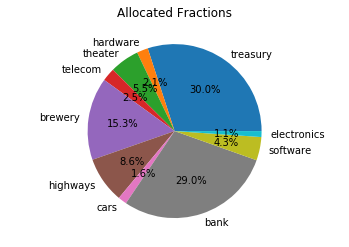

In [31]:
%matplotlib inline
import matplotlib.pyplot as plt

def display_pie(pie_values, pie_labels, colors=None,title=''):
    plt.axis("equal")
    plt.pie(pie_values, labels=pie_labels, colors=colors, autopct="%1.1f%%")
    plt.title(title)
    plt.show()
                                                           
display_pie( list(all_fracs.values()), list(all_fracs),title='Allocated Fractions')

## What-if analysis: trying different values for target return

The above model was solved with a 'hard coded' value of 9% for the target. 
Now, one can wonder how variance would vary if we changed this target return value.

In this part, we will leverage DOcplex model edition capabilities to explore different scenarios with different target return values.
We will run the model for target return values betwen 4% and 20%. For each possible target return value,
we modify the right-hand side (or _rhs_) of the `ct_target` constraint we kept as a variable, and solve again,
keeping the values in a list.


In [32]:
target_returns = range(5,21)  # from 5 to 20, included
variances = []
for target in target_returns:
    # modify the constraint's right hand side.
    ct_return.rhs = target
    cur_s = mdl.solve()
    assert cur_s  # solve is OK
    cur_variance = variance.solution_value
    print('- for a target return of: {0}%, variance={1}'.format(target, cur_variance))
    variances.append(cur_variance)

- for a target return of: 5%, variance=0.28105252209449944
- for a target return of: 6%, variance=0.28105252214416476
- for a target return of: 7%, variance=0.28105252225011274
- for a target return of: 8%, variance=0.30818590869638357
- for a target return of: 9%, variance=0.40557734940356227
- for a target return of: 10%, variance=0.5503435250054378
- for a target return of: 11%, variance=0.7417945731282698
- for a target return of: 12%, variance=0.9798459646928664
- for a target return of: 13%, variance=1.2598935443762442
- for a target return of: 14%, variance=1.5813755540443808
- for a target return of: 15%, variance=1.9442235946080064
- for a target return of: 16%, variance=2.3469592331334908
- for a target return of: 17%, variance=2.7889850545628727
- for a target return of: 18%, variance=3.2707284094234224
- for a target return of: 19%, variance=3.792503995389222
- for a target return of: 20%, variance=4.3543118101284675


Again we use `matplotlib` to print variances vs. target returns.

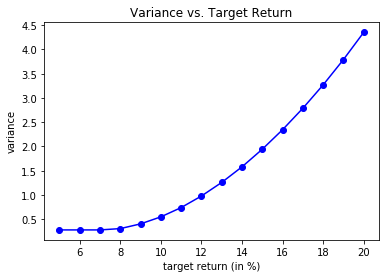

In [33]:
plt.plot(target_returns, variances, 'bo-')
plt.title('Variance vs. Target Return')
plt.xlabel('target return (in %)')
plt.ylabel('variance')
plt.show()

Not surprisingly, variance is increasing with target return.


# Summary

Having completed this notebook, you should be able to:

- Describe what a network model is, and the benefits of using network models

- Explain the concepts of nonlinearity and convexity

- Describe what a piecewise linear function is

- Describe the differences between:
  - Linear Programming (LP)
  - Integer Programming (IP)
  - Mixed-Integer Programming (MIP)
  - Quadratic Programming (QP)

- Construct a simple MIP model

## References
* [CPLEX Modeling for Python documentation](http://ibmdecisionoptimization.github.io/docplex-doc/)
* [IBM Decision Optimization](https://www.ibm.com/analytics/decision-optimization)
* Need help with DOcplex or to report a bug? Please go [here](https://stackoverflow.com/questions/tagged/docplex).
* Contact us at dofeedback@wwpdl.vnet.ibm.com.